In [1]:
import torch
from nns.memorygraphs.graph_memorypool import MemoryConfig, Controller, GmemoryI, GmemoryII, GmemoryIII, Gposition
from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
from trail.pic_tools import image_to_tensor, tensor_to_image_1channel

# 1. 初始化配置与核心模块
cfg = MemoryConfig()
cfg.H = 512
cfg.W = 512
# 如果使用 GPU，可以解注并设置：
# cfg.device = torch.device('cuda:0')

gmem_i = GmemoryI()
gmem_ii = GmemoryII(cfg)
gmem_iii = GmemoryIII(cfg)
gpos = Gposition(cfg)
controller = Controller(cfg)

# 2. 视觉前端特征提取器初始化
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
# 3. 加载测试图像
# image_path = 'picture/OIP-C.jpg'
image_path = '/home/p/code/ILSVRC/Data/DET/train/ILSVRC2014_train_0006/ILSVRC2014_train_00060030.JPEG'
tensor, original_image = image_to_tensor(image_path)
B, C, W_orig, H_orig = tensor.shape # 注意: 根据 image_to_tensor 返回，检查宽高顺序
# cfg.H = H_orig
# cfg.W = W_orig

# 4. 提取CNN特征
_, grad, hue, _, _, cropped = retina(tensor, center_x=-1, center_y=-1)
cur, asp, ori = msbank(cropped)

# 格式化各个子空间张量，确保它们是 [B, C_m, H, W]
# ※请注意：这里需要依赖您 CNN 呈递结果的具体形状，若 grad/hue 最后带有 channel=2 等，需在这里做维度重排或取模

grad = grad.squeeze(1).permute(0, 3, 1, 2)
edge_strength = torch.sqrt(grad[:,:1]**2 + grad[:,1:2]**2)
edge_ori = torch.atan2(grad[:,1:2], grad[:,:1])

edge = torch.cat([edge_strength, edge_ori, grad], dim=1)

X_subspaces = {
    0: edge,  # Modality 0: Edge
    1: cropped,   # Modality 1: RGB
    # 2: torch.nan_to_num(cur.detach(), nan=0.0),
    # 3: torch.nan_to_num(asp.detach(), nan=0.0),
    # 4: torch.nan_to_num(ori.detach(), nan=0.0)
}

# X_subspaces = {
#     0: edge,  # Modality 0: Edge
#     1: hue,   # Modality 1: Hue
#     2: torch.zeros_like(cur),
#     3: torch.zeros_like(asp),
#     4: torch.zeros_like(ori)
#     # 可后续按需加入:
#     # 2: cur, # Modality 2: Curvature 等
# }

# 将张量移动到对应执行设备
for k, v in X_subspaces.items():
    X_subspaces[k] = v.to(cfg.device)

In [3]:


# 5. 初始化控制器底层兴趣图
# controller.initialize_interest_map(X_subspaces, W, H, 3)
if controller.optimizer.base_interest is None:
      B, C, H, W = list(X_subspaces.values())[0].shape
      H_o = H_orig if H_orig is not None else H
      W_o = W_orig if W_orig is not None else W
      controller.optimizer.initialize_base_interest(X_subspaces, H_o, W_o)

controller.fixation_point = (335,225)
print(f"=== 初始控制器状态 ===")
print(f"Fixation Point: {controller.fixation_point}")
print(f"State: {controller.state.name}")
print("-" * 50)

# 6. 单步运行调度与打印


max_steps = 500  # 设定最大迭代步数


route = [controller.fixation_point[0], controller.fixation_point[1]]
dynamic_interest = []
base_interest = []
sum_I_spatial_I = []
sum_I_spatial_II = []
sum_I_exp = []
I_guide = []
semantic_mask = []
semantic_history = []
step_GmemII_sepratemark = []
test_m1 = []
test_m2 = []
test_m3 = []
test_m4 = []
prev_state = controller.state.LEARN_MACRO

for step in range(1, max_steps + 1):
    print(f"===========================")
    # 执行单步：Top-Down 匹配与 Bottom-Up 眼跳
    controller.run_step(X_subspaces, gmem_i, gmem_ii, gmem_iii, gpos)
    
    # 提取当前信息
    current_state = controller.state.name
    current_intention = controller.micro_intention.name
    fx, fy = controller.fixation_point
    num_gi_nodes = len(gmem_i.nodes)
    num_gii_nodes = len(gmem_ii.semantic_nodes)
    
    # 打印单步调试数据
    print(f"Step {step:03d} | "
          f"State: {current_state:<12} | "
          f"Inention: {current_intention:<12} | "
          f"Fixation: ({fx:4.1f}, {fy:4.1f}) | "
          f"GI Nodes: {num_gi_nodes:3d} | "
          f"GII Nodes: {num_gii_nodes:3d}")

    route.append(fx)
    route.append(fy)
    
    if step in [] and controller.optimizer.sum_I_spatial_II is not None:
      print("step ", step, "has sum_I_spatial_II")
      sum_I_spatial_II.append(tensor_to_image_1channel(controller.optimizer.sum_I_spatial_II))
    # if controller.semantic_mask is not None:
    #   semantic_mask.append(tensor_to_image_1channel(controller.semantic_mask))

    # if controller.matrix1 is not None:
    #   m1 = controller.matrix1
    #   test_m1.append(m1)
    #   m2 = controller.matrix2
    #   test_m2.append(m2)
      
    
    if prev_state != current_state and controller.semantic_mask is not None:
      print("has semantic_mask")
      print("semantic_mask ", controller.semantic_mask.max(), controller.semantic_mask.min())
      semantic_mask.append(controller.semantic_mask)
      semantic_history.append(controller.semantic_history)
      step_GmemII_sepratemark.append(step)

    if controller.matrix1 is not None:
      m1 = controller.matrix1
      test_m1.append(m1)

    '''
    if step in [7,8,9,10,11,12,13,14,15,16,17,18,19]:
      print(controller.current_interest_map.max())

    if step in [1,10,11,12]:
      dynamic_interest.append(tensor_to_image_1channel(controller.current_interest_map))
      base_interest.append(tensor_to_image_1channel(controller.optimizer.base_interest))
      sum_I_spatial_I.append(tensor_to_image_1channel(controller.optimizer.sum_I_spatial_I))
      sum_I_spatial_II.append(tensor_to_image_1channel(controller.optimizer.sum_I_spatial_II))
      sum_I_exp.append(tensor_to_image_1channel(controller.optimizer.sum_I_exp))
      I_guide.append(tensor_to_image_1channel(controller.optimizer.I_guide))
      semantic_mask.append(tensor_to_image_1channel(controller.semantic_mask))

    if step in [1,9,10,11,12] and controller.semantic_mask is not None:
      print("step ", step, "has semantic_mask")
      semantic_mask.append(tensor_to_image_1channel(controller.semantic_mask))
    '''
    prev_state = current_state

=== 初始控制器状态 ===
Fixation Point: (335, 225)
State: REVIEW
--------------------------------------------------
Step 001 | State: LEARN_MICRO  | Inention: INTERIOR_SAMPLE | Fixation: (347.0, 246.0) | GI Nodes:   1 | GII Nodes:   1
has semantic_mask
semantic_mask  tensor(1.) tensor(0.)
Step 002 | State: LEARN_MICRO  | Inention: INTERIOR_SAMPLE | Fixation: (330.0, 200.0) | GI Nodes:   1 | GII Nodes:   1
Step 003 | State: LEARN_MICRO  | Inention: INTERIOR_SAMPLE | Fixation: (351.0, 212.0) | GI Nodes:   1 | GII Nodes:   1
Step 004 | State: LEARN_MICRO  | Inention: BOUNDARY_SEEK | Fixation: (324.0, 248.0) | GI Nodes:   1 | GII Nodes:   1
Step 005 | State: LEARN_MICRO  | Inention: BOUNDARY_SEEK | Fixation: (378.0, 237.0) | GI Nodes:   1 | GII Nodes:   1
Step 006 | State: LEARN_MICRO  | Inention: CONTOUR_TRACE | Fixation: (328.0, 241.0) | GI Nodes:   3 | GII Nodes:   1
Step 007 | State: LEARN_MICRO  | Inention: CONTOUR_TRACE | Fixation: (324.0, 245.0) | GI Nodes:   4 | GII Nodes:   1
Step 008 | S

# Trail

In [4]:
from trail.pic_tools import *
from trail.matrix_tools import *
# from trail.viewrouteDraw import *
# import random
# from trail.foveated_visualization1 import visualize_step
import glob
import os

# print(controller.interest_map)

In [5]:
nid = 0
target_nodes = [gmem_i.nodes[nid]]
S_maps = {}
active_nodes = [n for n in target_nodes]
for node in active_nodes:
    mod_id = node.modality_id
    X_m = X_subspaces.get(mod_id)
    if X_m is None:
        continue
        
    w_m = node.prototype.to("cpu").view(1, -1, 1, 1)
    S_m = torch.sum(X_m * w_m, dim=1, keepdim=True)
    
    weight = 1
    S_maps[node.node_id] = S_m * weight

print(X_subspaces[0][0,:,250,319])
print(X_subspaces[0][0,:,252,354])
print(w_m)
print(S_m[0,:,250,319])
print(S_m[0,:,252,354])

tensor([ 4.5560, -0.7713,  3.2667, -3.1759])
tensor([ 2.1212, -1.2440,  0.6808, -2.0090])
tensor([[[[0.4966]],

         [[0.3872]],

         [[0.2734]]]])
tensor([0.2909])
tensor([0.2828])


1
tensor([0.4966, 0.3872, 0.2734])
torch.Size([1, 1, 512, 512]) tensor(0.) tensor(0.5998)
torch.Size([1, 1, 512, 512]) tensor(0.) tensor(1.)
tensor([0.0021]) tensor([0.0293])


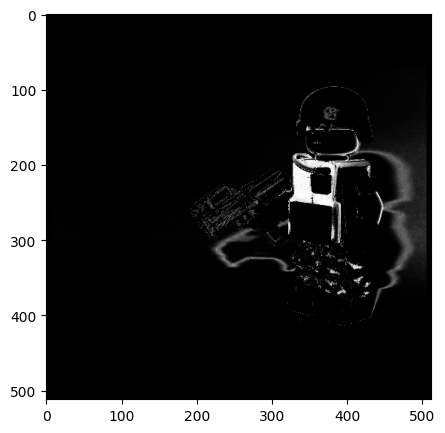

In [6]:
nid = 0
print(gmem_i.nodes[nid].modality_id)
print(gmem_i.nodes[nid].prototype)

node_id1_footprint = gpos.l1_footprint_projection(X_subspaces,[gmem_i.nodes[nid]])
footp_nid1 = node_id1_footprint[gmem_i.nodes[nid].node_id]

footp_nid1 = footp_nid1.clamp(min = 0.0)
print(footp_nid1.shape, footp_nid1.min(), footp_nid1.max())
footp_nid1 = (footp_nid1 - footp_nid1.min()) / (footp_nid1.max() - footp_nid1.min())
print(footp_nid1.shape, footp_nid1.min(), footp_nid1.max())
print(footp_nid1[0,:,329,187], footp_nid1[0,:,252,354])

fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(footp_nid1))
plt.show()

## route

In [7]:
print(step_GmemII_sepratemark)

[1, 23, 36, 40, 104, 120]


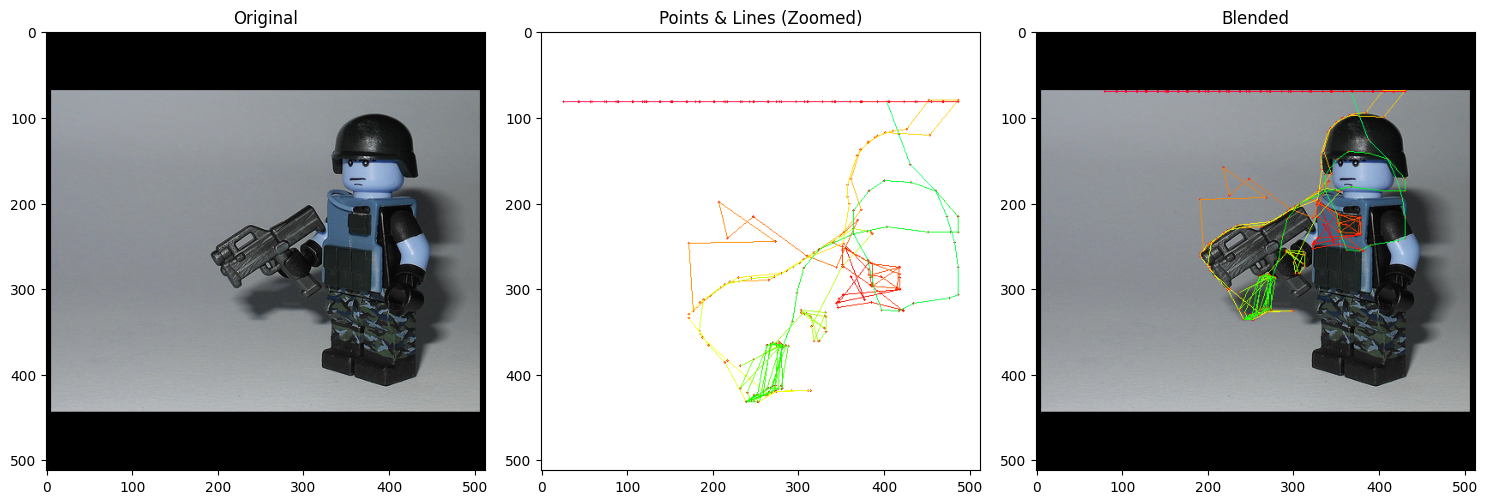

In [8]:
from trail.viewrouteDraw import debug_mark_advanced, debug_show, tensor_sequence_to_gif, debug_mark_advanced_gif
import cv2
import matplotlib.pyplot as plt

x1=0
x2=300

debug_mark_advanced(
    image_input=cropped,
    # points=route[x1*2:x2*2],
    points=route,
    point_size=1,
    line_thickness=1,
    draw_points=True,
    draw_lines=True,
    gradient_lines=True,
    start_hue=0.0,           # 从红色开始
    background_color=(255,255,255),  # 白色背景
    # output_path = "blended099.png",
    display_in_notebook=True
)



In [9]:
# debug_mark_advanced_gif(
#     image_input= cropped,
#     # points=route[x1*2:x2*2],
#     points=route,
#     draw_points=True,
#     draw_lines=True,
#     gradient_lines=True,
#     output_path="blended.png",
#     gif_output="animation.gif",    # 输出动图
#     gif_fps=5,
#     return_images=False
# )

## Interest

6


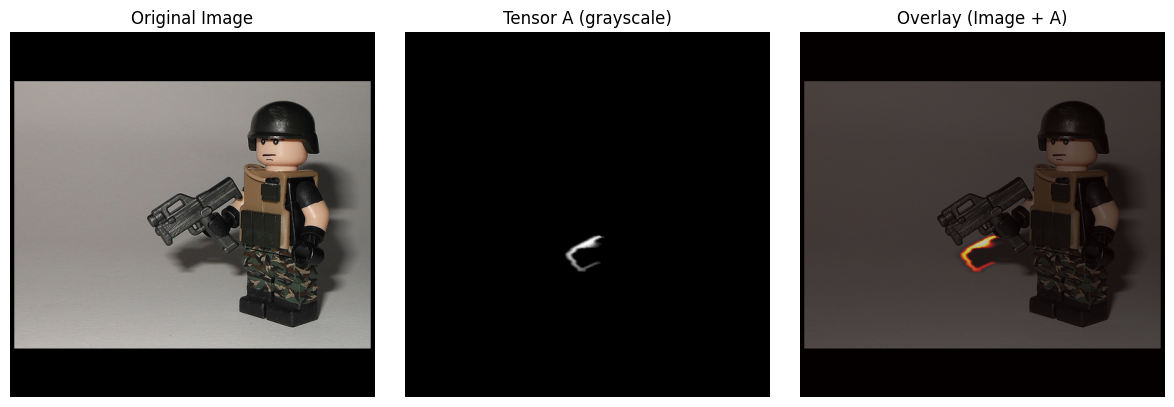

In [59]:
print(len(semantic_mask))
debug_show(cropped, semantic_mask[5])

In [11]:
k = 0

In [12]:
k = k+1
print(k)

1


500


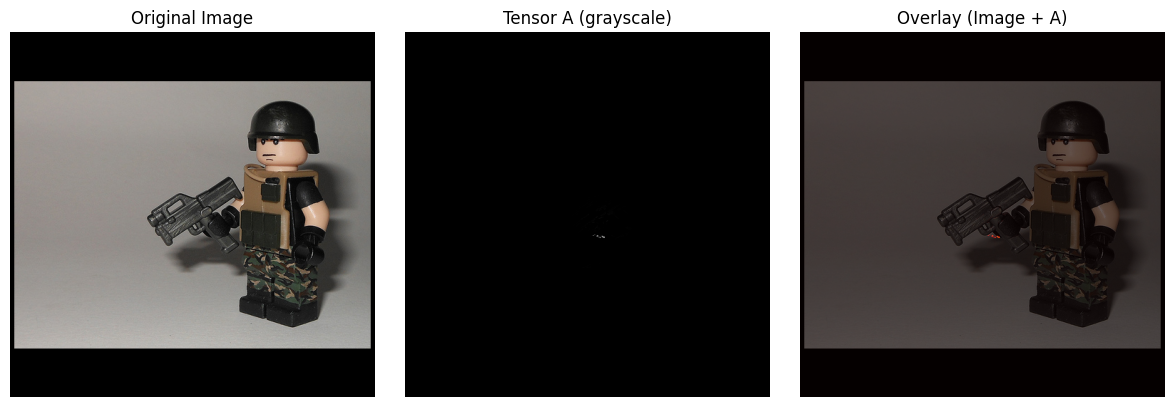

In [49]:
print(len(test_m1))
debug_show(cropped, test_m1[132])

In [14]:
picnum = len(test_m2)
print(picnum)
debug_show(cropped, test_m2[33])

0


IndexError: list index out of range

In [ ]:
fang = test_m2[22:33]
tensor_sequence_to_gif(fang, 'demo2.gif', fps=3)

GIF 已保存至: demo2.gif （共 11 帧，3 fps）


TypeError: Invalid shape (1, 1, 512, 512) for image data

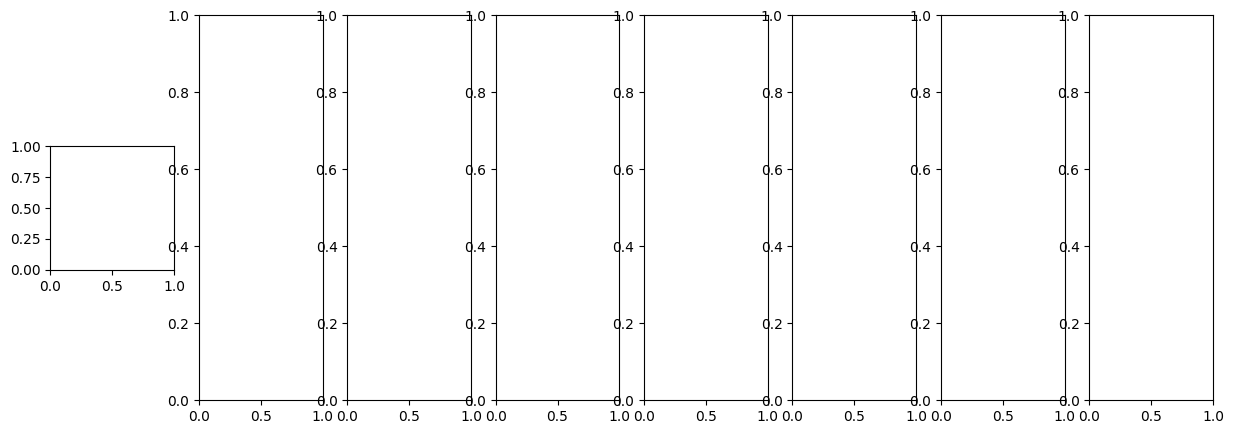

In [ ]:
A = semantic_history[6:14]
picnum = len(A)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, A):
    ax.imshow(image)

plt.show()

25


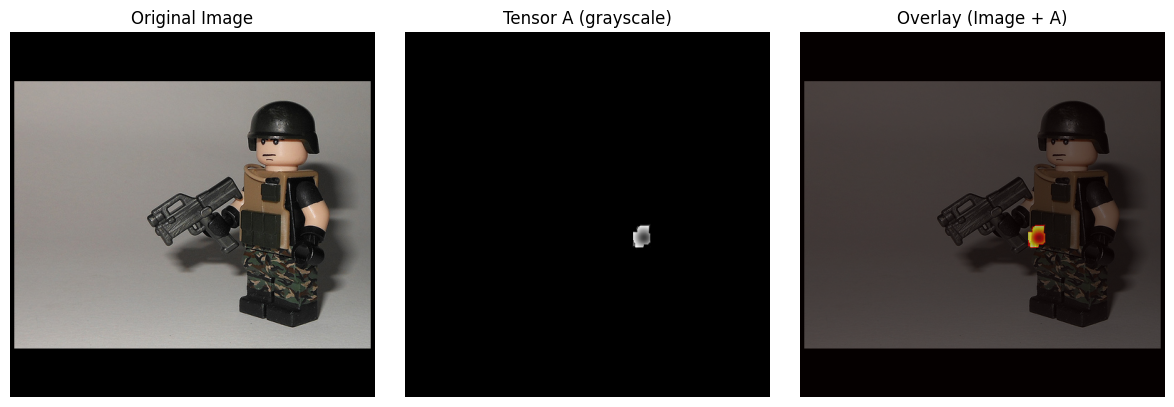

In [ ]:
print(len(semantic_mask))
debug_show(cropped, semantic_mask[24])

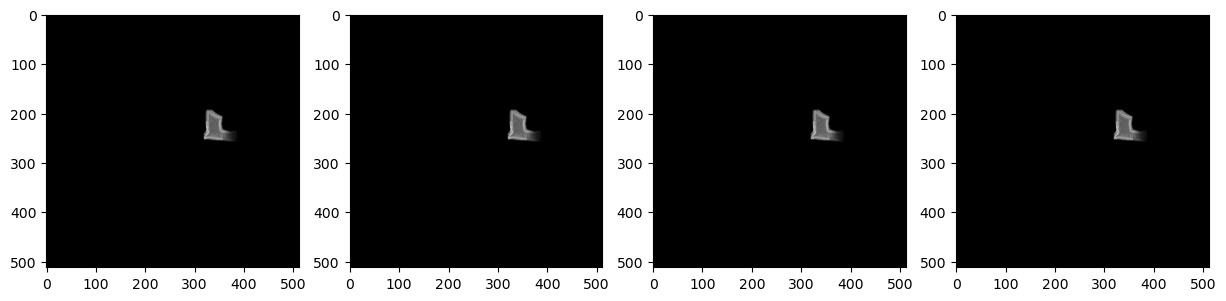

In [ ]:
picnum = len(dynamic_interest)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, dynamic_interest):
    ax.imshow(image)

plt.show()

### base interest

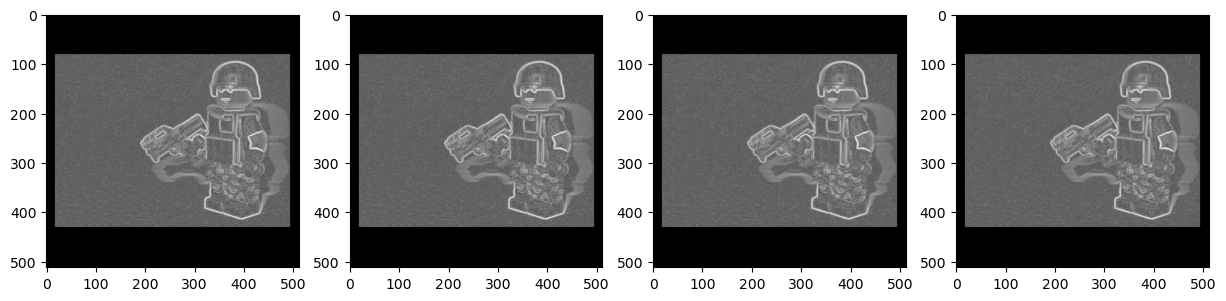

In [ ]:
picnum = len(base_interest)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, base_interest):
    ax.imshow(image)

plt.show()

tensor(3.9910) tensor(0.)
tensor(0.6000) tensor(0.)
tensor(0.7000) tensor(0.0027)


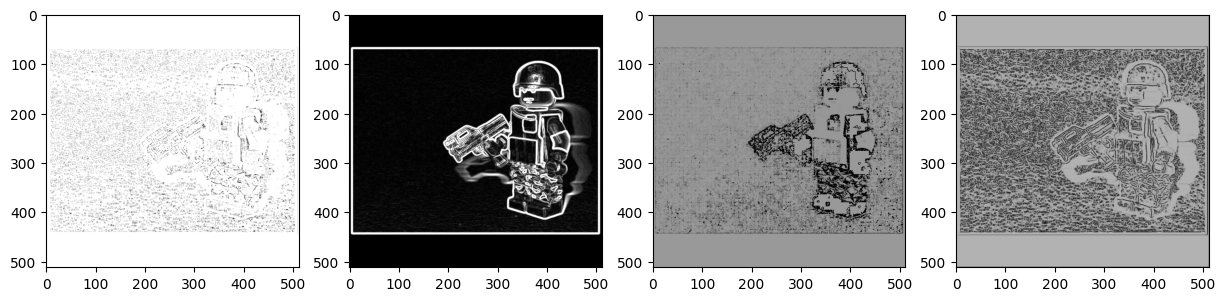

In [ ]:
print(controller.optimizer.I_str.max(), controller.optimizer.I_str.min())
print(controller.optimizer.I_con1.max(), controller.optimizer.I_con1.min())
print(controller.optimizer.I_con2.max(), controller.optimizer.I_con2.min())
I_base = controller.optimizer.I_str + controller.optimizer.I_con1 + controller.optimizer.I_con2

I_compromize = []
I_compromize.append(tensor_to_image_1channel(I_base))
I_compromize.append(tensor_to_image_1channel(controller.optimizer.I_str))
I_compromize.append(tensor_to_image_1channel(controller.optimizer.I_con1))
I_compromize.append(tensor_to_image_1channel(controller.optimizer.I_con2))

picnum = len(I_compromize)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, I_compromize):
    ax.imshow(image)

plt.show()

In [ ]:
picnum = len(sum_I_spatial_I)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, sum_I_spatial_I):
    ax.imshow(image)

plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x500 with 0 Axes>

In [ ]:
picnum = len(sum_I_spatial_II)
print(picnum)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, sum_I_spatial_II):
    ax.imshow(image)

plt.show()

0


ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x500 with 0 Axes>

In [ ]:
picnum = len(sum_I_exp)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, sum_I_exp):
    ax.imshow(image)

plt.show()

In [ ]:
picnum = len(I_guide)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, I_guide):
    ax.imshow(image)

plt.show()

## semantic_mask

TypeError: 'Axes' object is not iterable

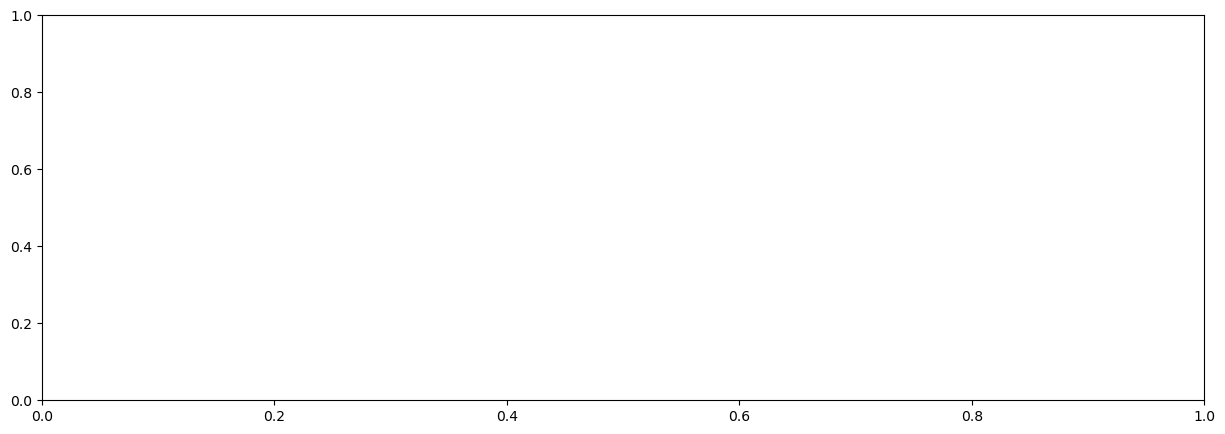

In [ ]:

picnum = len(semantic_mask)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, semantic_mask):
    ax.imshow(image)

plt.show()



1
tensor(0.2000) tensor(0.9229)


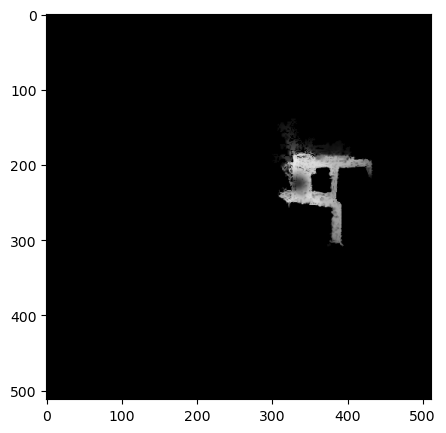

In [ ]:
print(len(semantic_mask))
sm = semantic_mask[0]
print(sm[0,0,225,335], sm[0,0,194,333])
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(sm))
plt.show()

10
tensor(1.)
tensor(0.)
tensor(1.) tensor(0.9293)
tensor(1.) tensor(0.9293)


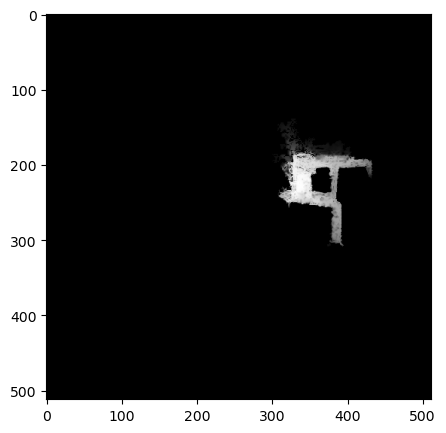

In [ ]:
print(len(test_m1))
m1 = test_m1[0]
print(m1.max())
print(m1.min())
print(m1[0,0,225,335], m1[0,0,194,333])
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(m1))
plt.show()

10
tensor(1.)
tensor(0.)


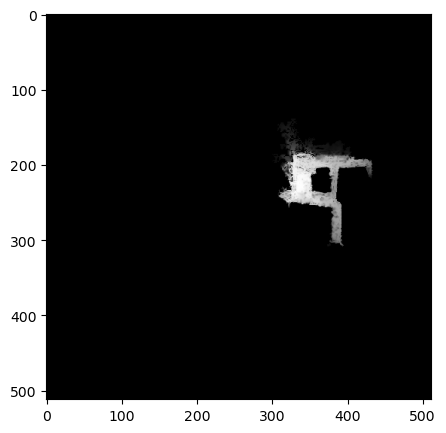

In [ ]:
print(len(test_m2))
m2 = test_m2[0]
print(m2.max())
print(m2.min())
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(m2))
plt.show()

tensor(1.)
tensor(0.)


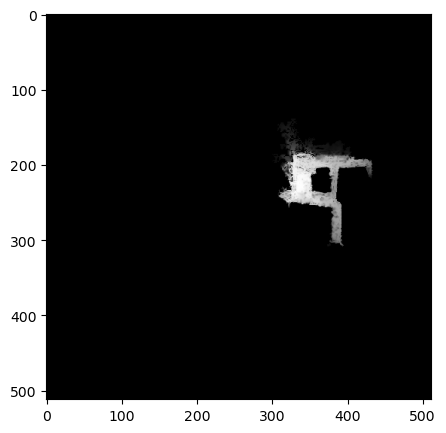

In [ ]:
m3 = test_m3[0]
print(m3.max())
print(m3.min())
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(m3))
plt.show()

In [ ]:
m4 = test_m4[2]
print(m4.max())
print(m4.min())
fig, axes = plt.subplots(1, 1, figsize=(15, 5))
axes.imshow(tensor_to_image_1channel(m4))
plt.show()

In [ ]:
mlist = controller.matrix2
picnum = len(mlist)
print(len(mlist))

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, mlist):
    print(image.max())
    ax.imshow(tensor_to_image_1channel(image))

plt.show()



# RUN ABOVE


# folder pic

In [ ]:
'''
folder_path = '/home/p/code/ILSVRC/Data/DET/train/ILSVRC2014_train_0006'

# image_paths = glob.glob(os.path.join(folder_path, '*.JPEG'))

image_paths = glob.iglob(folder_path + '/*.JPEG')
pic = 1
for image_path in image_paths:
    print(f"Picture {pic}")
    pic += 1
    
    tensor, oringinal_image = image_to_tensor(image_path)
    B, C, W, H = tensor.shape

    # retina_out = retina(tensor, center_x = -1, center_y = -1)
    _, grad, hue, _, _, cropped = retina(tensor, center_x = -1, center_y = -1)
    # msfb_out = msbank(cropped)
    cur, asp, ori = msbank(cropped)


    step = 1
    mc.handle_new_view({'grad': grad, 'hue': hue, 'curvature': cur, 'aspect': asp, 'orientation': ori})
    step += 1

    while step < 200:
        mc.handle_new_view({'grad': grad, 'hue': hue, 'curvature': cur, 'aspect': asp, 'orientation': ori})
        step += 1

    print(f"Step {step}, graph1 nodes in total = {mc.graphI.graphI[0]._next_proto_id} ")
    print(f"Step {step}, graph2 nodes in total = {mc.graphII.next_graph2_id} ")

    mc.graphI.reset_all_buckets()
    # if 5 == pic:
    #     break
'''


# trail tools